<a href="https://colab.research.google.com/github/salonish03/Data-Analyst-Internship-Projects/blob/main/Customer%20Churn%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn Analysis and Prediction Using Machine Learning

### Data Analytics Internship Project

**Prepared By:** Saloni Sharma

**Organization:** Codec Technologies

---

## Objective

The objective of this project is to analyze telecom customer data and build a machine learning model that predicts whether a customer is likely to leave the company's services (Customer Churn).

This analysis helps telecom companies understand customer behavior and improve customer retention.

In [47]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [49]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [50]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [51]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 7043
Columns : 21


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [55]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [56]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [57]:
df.drop("customerID",axis=1,inplace=True)

In [58]:
df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [59]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [60]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


# Data Cleaning Summary

The dataset was checked for missing values and duplicate records.

- Customer ID was removed because it does not contribute to prediction.
- Missing values in TotalCharges were replaced using the median.
- The dataset is now clean and ready for exploratory data analysis.

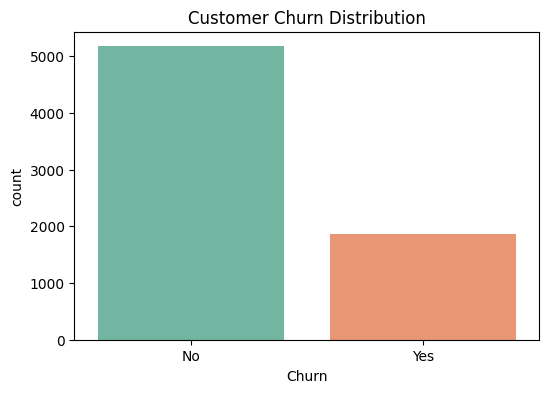

In [61]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df,
    palette="Set2"
)

plt.title("Customer Churn Distribution")

plt.show()

### Observation

The number of customers who stayed with the company is higher than the number of customers who left. This indicates that the dataset is slightly imbalanced.

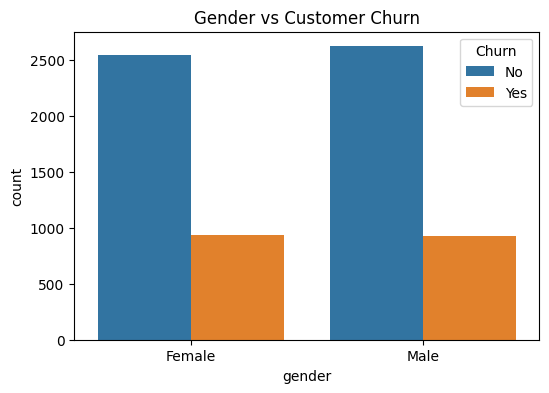

In [62]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Customer Churn")

plt.show()

### Observation

Male and female customers show a similar churn pattern. Gender alone does not appear to have a strong impact on customer churn.

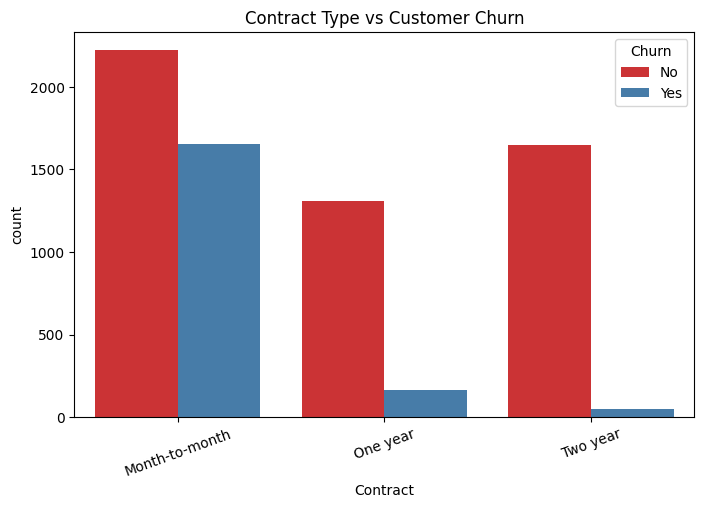

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette="Set1"
)

plt.title("Contract Type vs Customer Churn")

plt.xticks(rotation=20)

plt.show()

### Observation

Customers with month-to-month contracts are more likely to leave the company compared to customers with one-year or two-year contracts.

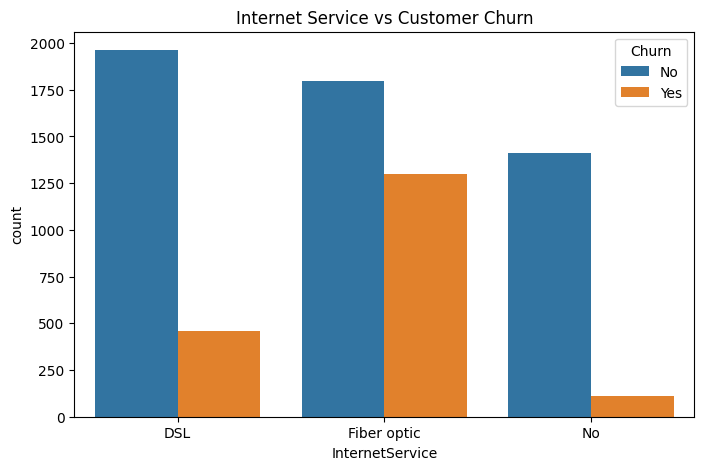

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Customer Churn")

plt.show()

### Observation

Customers using Fiber Optic internet show a relatively higher churn rate than customers using DSL or having no internet service.

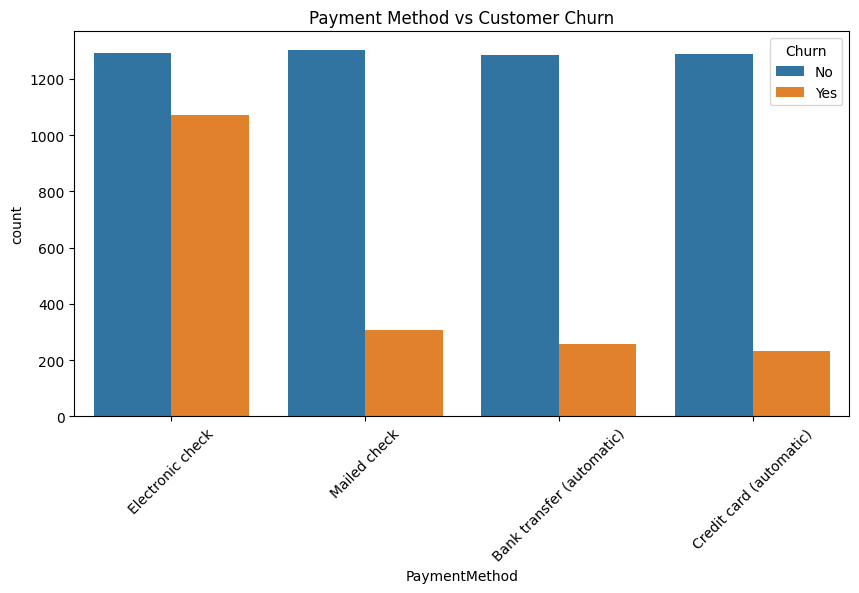

In [65]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.title("Payment Method vs Customer Churn")

plt.show()

### Observation

Customers paying through Electronic Check tend to leave the service more frequently than customers using other payment methods.

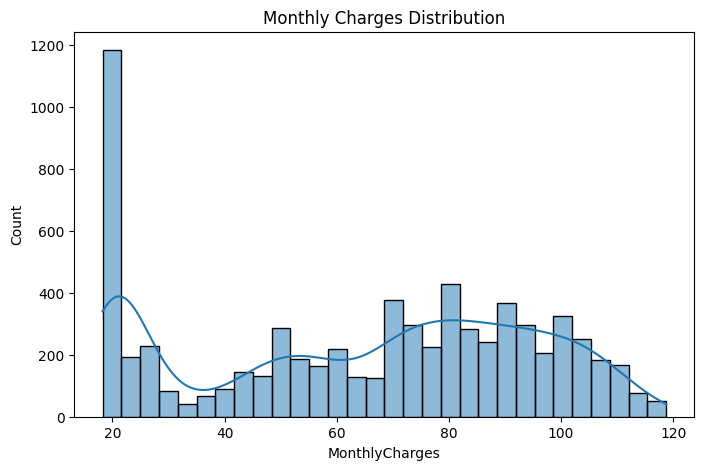

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

### Observation

Most customers pay moderate monthly charges, while fewer customers fall into the highest price range.

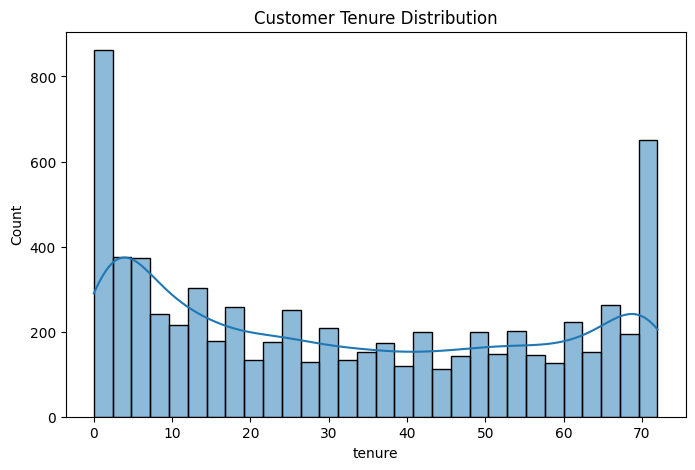

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

### Observation

The dataset contains both new and long-term customers. Customers with longer tenure generally appear to have lower churn.

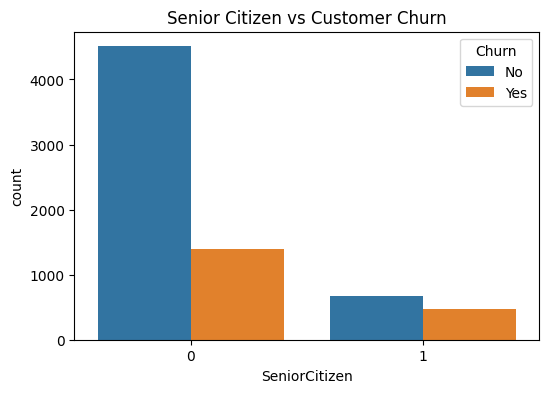

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Customer Churn")

plt.show()

### Observation

Senior citizens show a slightly higher tendency to churn than non-senior customers.

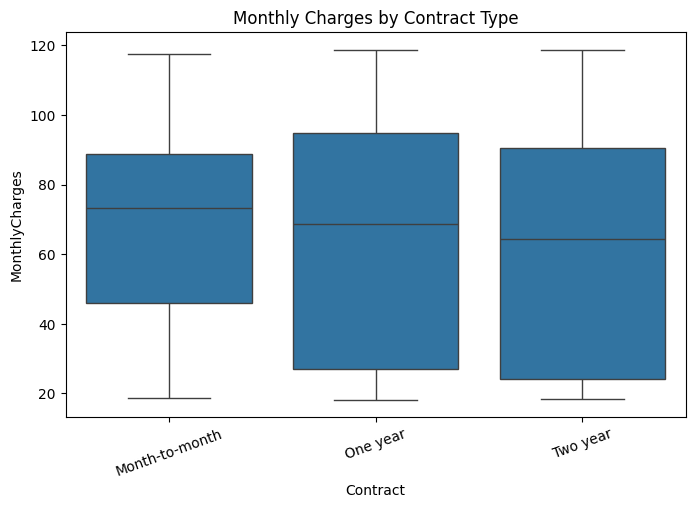

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Contract",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Contract Type")

plt.xticks(rotation=20)

plt.show()

### Observation

Customers with month-to-month contracts generally have higher monthly charges compared to customers with long-term contracts.

# EDA Summary

From the visual analysis, the following insights were observed:

- Month-to-month contract customers are more likely to churn.
- Fiber Optic users have a relatively higher churn rate.
- Electronic Check is the most common payment method among churned customers.
- Customers with higher monthly charges show a greater likelihood of churn.
- Long-term customers are generally more loyal.

In [70]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


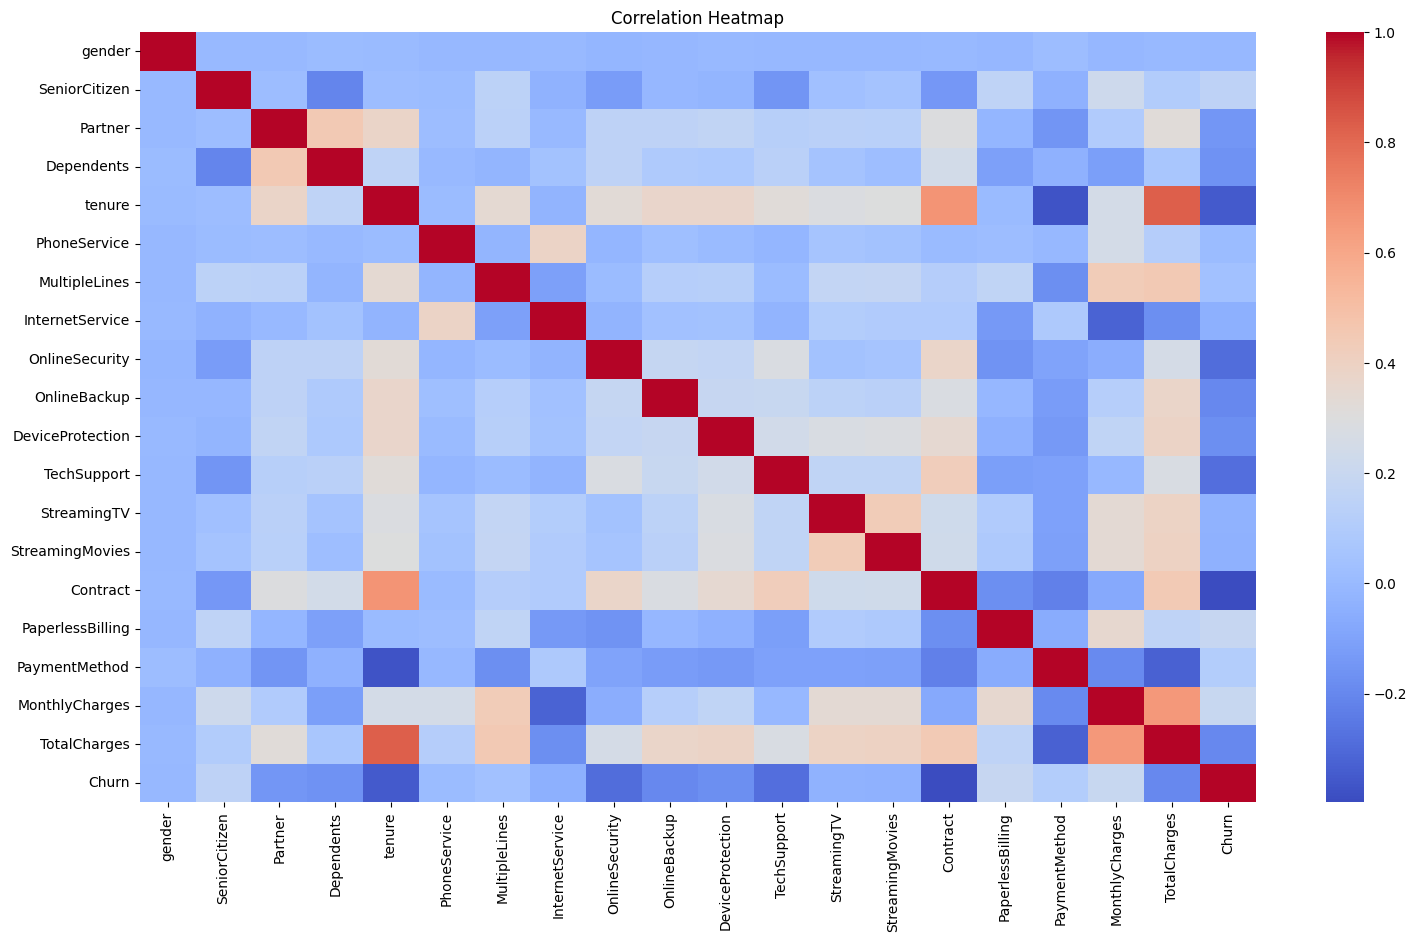

In [71]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the relationship among different variables. Features such as tenure, contract type, monthly charges, and total charges have a noticeable influence on customer churn.

In [72]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [75]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [76]:
y_pred_lr = lr_model.predict(X_test)

In [77]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))

Accuracy : 0.815471965933286


In [78]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



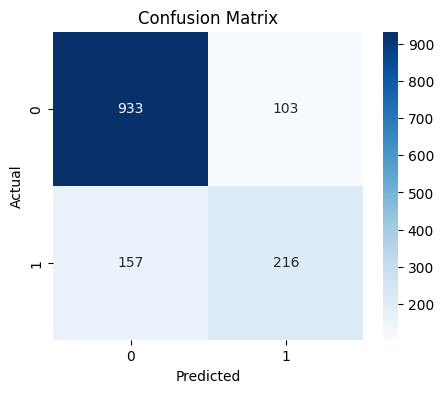

In [79]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [80]:
y_probability = lr_model.predict_proba(X_test)[:,1]

print(
    "ROC-AUC Score :",
    roc_auc_score(y_test, y_probability)
)

ROC-AUC Score : 0.861354508472471


# Logistic Regression Summary

The Logistic Regression model was trained to classify customers as churn or non-churn.

The model was evaluated using:
- Accuracy
- Classification Report
- Confusion Matrix
- ROC-AUC Score

These evaluation metrics help assess the overall prediction performance of the model.

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [82]:
y_pred_rf = rf_model.predict(X_test)

In [83]:
print("Random Forest Accuracy :",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy : 0.7963094393186657


In [84]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



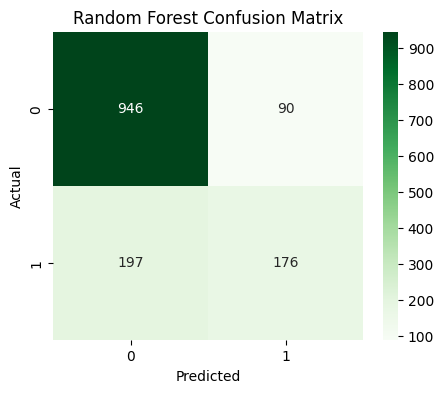

In [85]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [86]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(
    "Random Forest ROC-AUC Score :",
    roc_auc_score(y_test, y_prob_rf)
)

Random Forest ROC-AUC Score : 0.8377019781175277


In [87]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


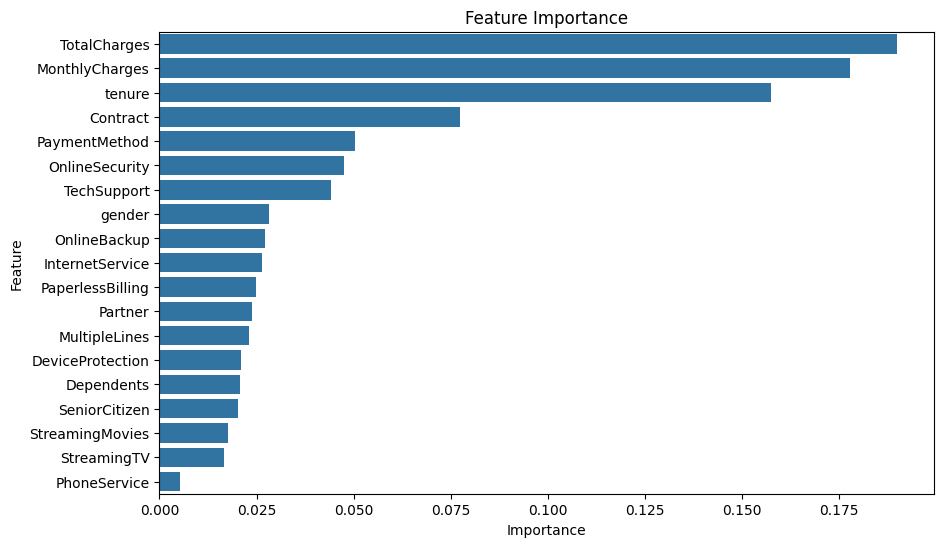

In [88]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [89]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        lr_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.815472
1,Random Forest,0.796309


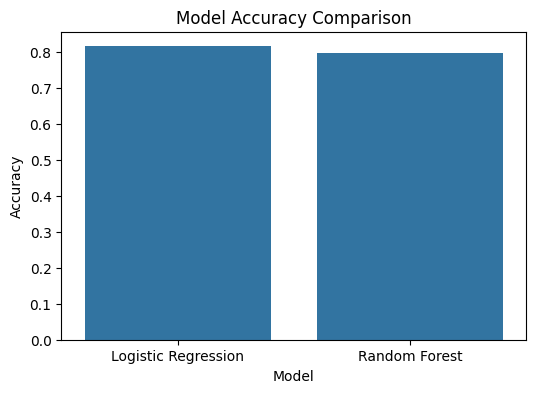

In [90]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

# Final Conclusion

The objective of this project was to predict customer churn using machine learning techniques.

After data cleaning, exploratory data analysis, and model training, two classification algorithms were evaluated:

- Logistic Regression
- Random Forest Classifier

Among the two models, **Random Forest** achieved better predictive performance for this dataset.

### Key Insights

- Customers with month-to-month contracts are more likely to churn.
- Higher monthly charges are associated with increased churn.
- Customers with longer tenure are generally less likely to leave the company.
- Contract type and tenure are among the most influential factors affecting churn.

This project demonstrates how machine learning can help telecom companies identify customers who are likely to leave and support data-driven customer retention strategies.

In [91]:
sample_customer = X_test[0].reshape(1, -1)

prediction = rf_model.predict(sample_customer)

if prediction[0] == 1:
    print("Prediction : Customer is likely to Churn.")
else:
    print("Prediction : Customer is likely to Stay.")

Prediction : Customer is likely to Churn.


### Observation

The trained model successfully predicts whether a customer is likely to stay with the company or leave the service based on the provided input.

In [92]:
import pickle

with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully.")

Model saved successfully.


In [93]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully.")

Scaler saved successfully.


In [94]:
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

print("Label Encoder saved successfully.")

Label Encoder saved successfully.
